In [42]:
# CELL 1:  SETUP & DEPENDENCIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from scipy import stats

# ML Models
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, 
    precision_recall_curve, confusion_matrix, roc_curve
)

# Explainability
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Enterprise Libraries Loaded Successfully.")

✅ Enterprise Libraries Loaded Successfully.


In [43]:
# ==============================================================================
# CELL 2: DATA INGESTION
# ==============================================================================
DATA_PATH = r"D:\AfrFile\Project_Pribadi\DiabetesDetection\data\diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset Loaded: {df.shape[0]:,} Rows | {df.shape[1]} Columns")
display(df.head())

✅ Dataset Loaded: 253,680 Rows | 22 Columns


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [44]:
# CELL 3: DATA QUALITY CHECKS
print('=== Missing Values ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✅ No missing values found. Dataset is complete.')
else:
    print(missing[missing > 0])

print('\n=== Duplicate Rows ===')
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates:,} ({(duplicates/len(df))*100:.2f}%)')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'✅ After removal, new shape: {df.shape}')

=== Missing Values ===
✅ No missing values found. Dataset is complete.

=== Duplicate Rows ===
Duplicate rows: 24,206 (9.54%)
✅ After removal, new shape: (229474, 22)


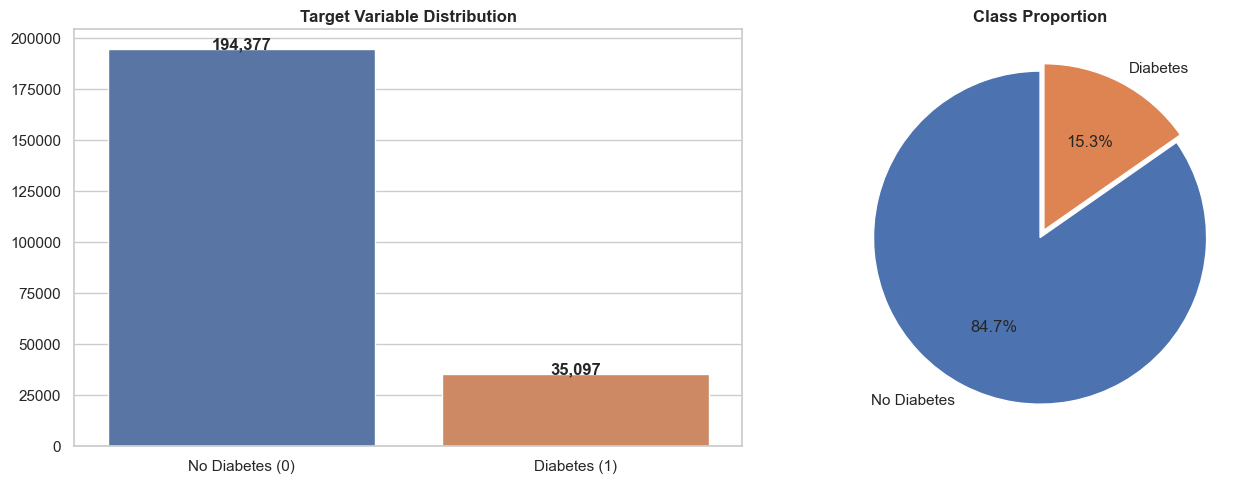

⚠️ Clinical Reality: Imbalance Ratio is 5.54:1


In [45]:
# ==============================================================================
# CELL 4: TARGET VARIABLE ANALYSIS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_counts = df['Diabetes_binary'].value_counts()

# Bar Chart
sns.barplot(x=['No Diabetes (0)', 'Diabetes (1)'], y=target_counts.values, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Target Variable Distribution', fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(target_counts.values, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%', 
            colors=['#4C72B0', '#DD8452'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"⚠️ Clinical Reality: Imbalance Ratio is {imbalance_ratio:.2f}:1")

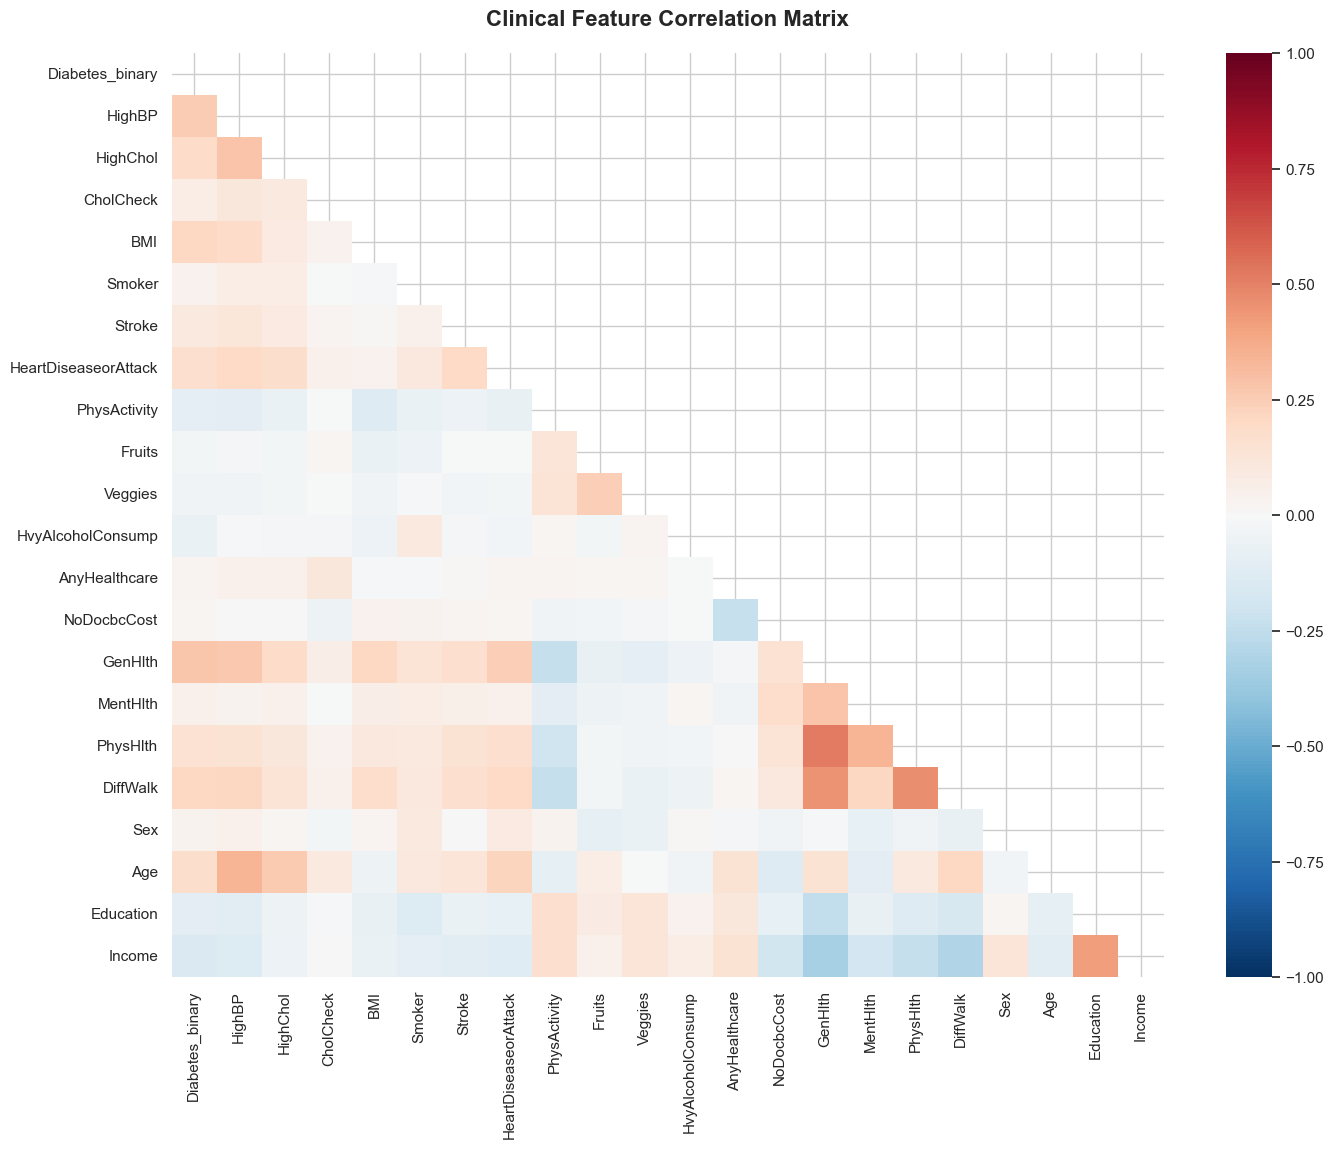


=== Top 7 Features Correlated with Diabetes ===
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
Name: Diabetes_binary, dtype: float64


In [46]:
# ==============================================================================
# CELL 5: DEEP EDA - CORRELATION MATRIX
# ==============================================================================
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Clinical Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.show()

print('\n=== Top 7 Features Correlated with Diabetes ===')
print(corr_matrix['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False).head(7))

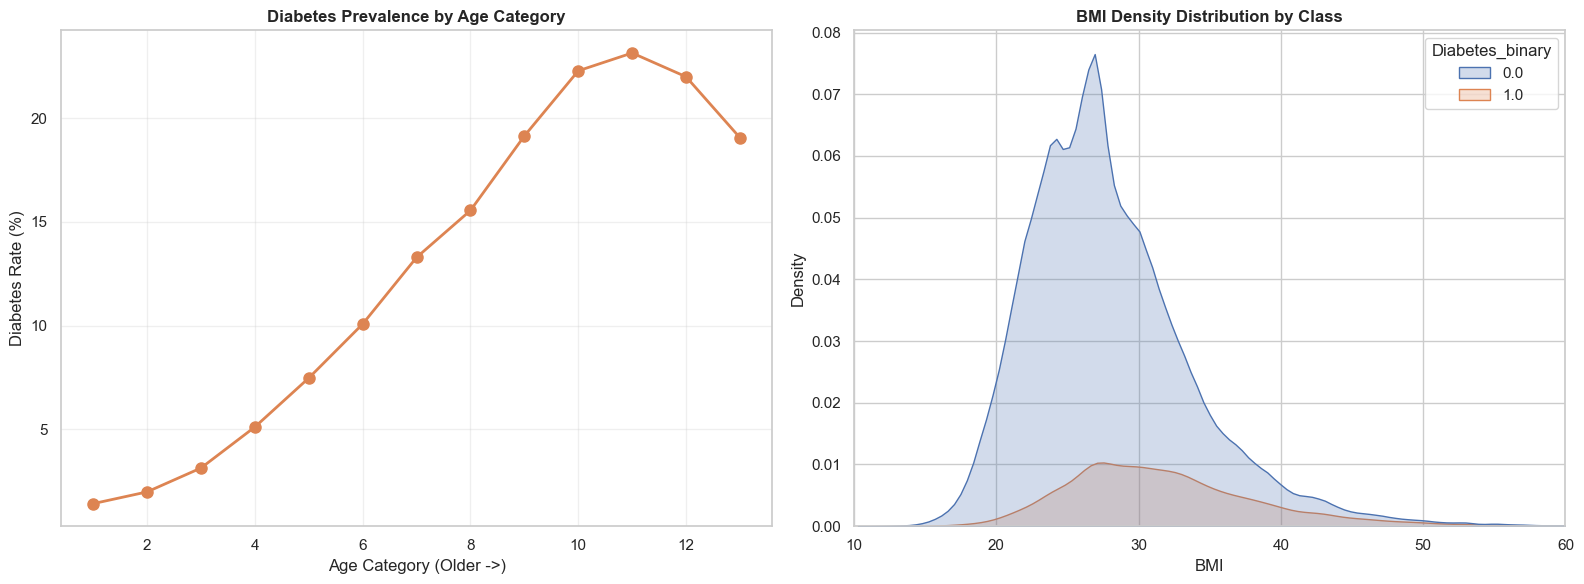

In [47]:
# CELL 6: DEMOGRAPHICS vs RISK (Age & BMI)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Diabetes Rate
age_rate = df.groupby('Age')['Diabetes_binary'].mean() * 100
axes[0].plot(age_rate.index, age_rate.values, 'o-', color='#DD8452', linewidth=2, markersize=8)
axes[0].set_title('Diabetes Prevalence by Age Category', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_xlabel('Age Category (Older ->)')
axes[0].grid(True, alpha=0.3)

# BMI Distribution by Class
sns.kdeplot(data=df, x='BMI', hue='Diabetes_binary', ax=axes[1], fill=True, palette=['#4C72B0', '#DD8452'])
axes[1].set_title('BMI Density Distribution by Class', fontweight='bold')
axes[1].set_xlim(10, 60) # Fokus pada range utama

plt.tight_layout()
plt.show()

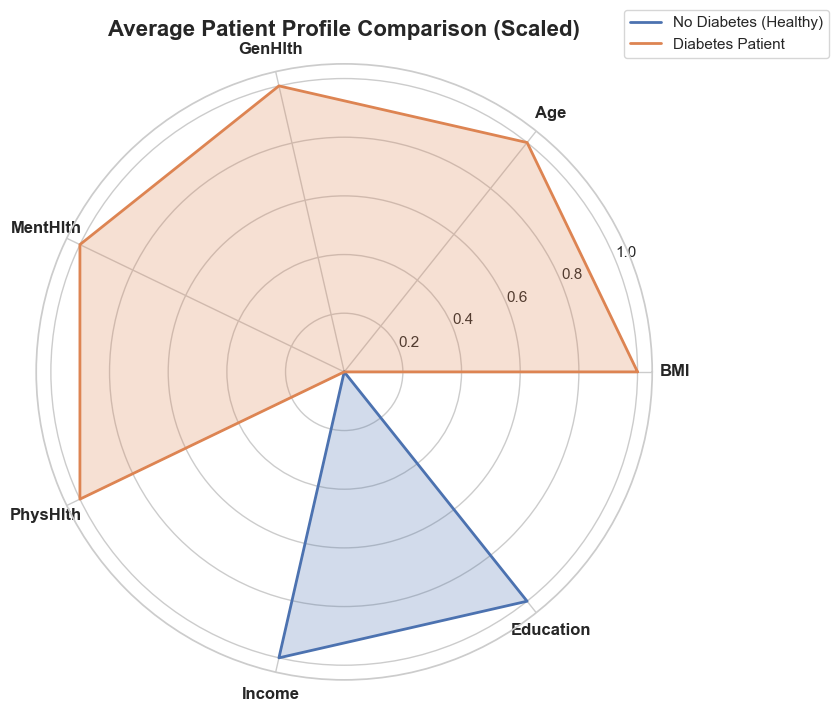

In [48]:
# ==============================================================================
# CELL 7: CLINICAL PATIENT PROFILING (RADAR CHART)
# ==============================================================================
from sklearn.preprocessing import MinMaxScaler
import math

# Pilih fitur-fitur gaya hidup dan fisik utama
radar_features = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education']
radar_data = df[radar_features + ['Diabetes_binary']].groupby('Diabetes_binary').mean().reset_index()

# MinMax Scaling agar semua nilai berada di skala 0-1 untuk visualisasi radar
scaler_radar = MinMaxScaler()
radar_scaled = pd.DataFrame(scaler_radar.fit_transform(radar_data.drop('Diabetes_binary', axis=1)), columns=radar_features)

# Setup Polar Plot
categories = radar_features
N = len(categories)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot Pasien Sehat (Class 0)
values_0 = radar_scaled.iloc[0].values.flatten().tolist()
values_0 += values_0[:1]
ax.plot(angles, values_0, linewidth=2, linestyle='solid', label='No Diabetes (Healthy)', color='#4C72B0')
ax.fill(angles, values_0, '#4C72B0', alpha=0.25)

# Plot Pasien Diabetes (Class 1)
values_1 = radar_scaled.iloc[1].values.flatten().tolist()
values_1 += values_1[:1]
ax.plot(angles, values_1, linewidth=2, linestyle='solid', label='Diabetes Patient', color='#DD8452')
ax.fill(angles, values_1, '#DD8452', alpha=0.25)

plt.xticks(angles[:-1], categories, size=12, fontweight='bold')
ax.set_title('Average Patient Profile Comparison (Scaled)', size=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [49]:
# ==============================================================================
# CELL 8: STATISTICAL TESTS (Chi-Square & Mann-Whitney U)
# ==============================================================================
print('=== Statistical Validation: Do these features matter? ===\n')

print("1. Mann-Whitney U Test (Continuous Features)")
for col in ['BMI', 'MentHlth', 'PhysHlth']:
    g0, g1 = df[df['Diabetes_binary'] == 0][col], df[df['Diabetes_binary'] == 1][col]
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = 'Yes ***' if p_val < 0.001 else 'No'
    print(f' - {col:<10} | p-value: {p_val:<10.2e} | Significant: {sig}')

print("\n2. Chi-Square Test (Key Binary Features)")
for col in ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'DiffWalk']:
    ct = pd.crosstab(df[col], df['Diabetes_binary'])
    chi2_stat, p_val, _, _ = stats.chi2_contingency(ct)
    sig = 'Yes ***' if p_val < 0.001 else 'No'
    print(f' - {col:<20} | p-value: {p_val:<10.2e} | Significant: {sig}')

=== Statistical Validation: Do these features matter? ===

1. Mann-Whitney U Test (Continuous Features)
 - BMI        | p-value: 0.00e+00   | Significant: Yes ***
 - MentHlth   | p-value: 1.10e-19   | Significant: Yes ***
 - PhysHlth   | p-value: 0.00e+00   | Significant: Yes ***

2. Chi-Square Test (Key Binary Features)
 - HighBP               | p-value: 0.00e+00   | Significant: Yes ***
 - HighChol             | p-value: 0.00e+00   | Significant: Yes ***
 - HeartDiseaseorAttack | p-value: 0.00e+00   | Significant: Yes ***
 - DiffWalk             | p-value: 0.00e+00   | Significant: Yes ***


In [50]:
# ==============================================================================
# CELL 9: ADVANCED FEATURE ENGINEERING (Domain Knowledge Injection)
# ==============================================================================
df_eng = df.copy()

# 1. Cardio-Metabolic Indicators
df_eng['Metabolic_Syndrome'] = df_eng['HighBP'] + df_eng['HighChol'] + (df_eng['BMI'] > 30.0).astype(float)
df_eng['CardioRisk'] = df_eng['HighBP'] + df_eng['HighChol'] + df_eng['Stroke'] + df_eng['HeartDiseaseorAttack']

# 2. Behavioral & Lifestyle
df_eng['LifestyleScore'] = df_eng['PhysActivity'] + df_eng['Fruits'] + df_eng['Veggies'] - df_eng['HvyAlcoholConsump'] - df_eng['Smoker']

# 3. Socio-Economic Ratios (+1 to avoid div-by-zero)
df_eng['Age_to_Income_Ratio'] = df_eng['Age'] / (df_eng['Income'] + 1.0)
df_eng['HealthAccess'] = df_eng['AnyHealthcare'] - df_eng['NoDocbcCost']

TARGET = 'Diabetes_binary'
y = df_eng[TARGET]
X = df_eng.drop(TARGET, axis=1)
feature_names = X.columns.tolist()

print(f"✅ Feature Engineering Complete. Expanded from {df.shape[1]-1} to {X.shape[1]} features.")

✅ Feature Engineering Complete. Expanded from 21 to 26 features.


In [51]:
# ==============================================================================
# CELL 10: STRATIFIED SPLIT & SANITY CHECK
# ==============================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Sanity Check to prevent Covariate Shift
train_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
test_ratio = y_test.value_counts()[0] / y_test.value_counts()[1]

print("🔍 [SANITY CHECK] Verifying Class Imbalance After Split...")
print(f" - Original Ratio : {imbalance_ratio:.4f}")
print(f" - Train Ratio    : {train_ratio:.4f}")
print(f" - Test Ratio     : {test_ratio:.4f}")

assert abs(imbalance_ratio - train_ratio) < 0.05, "CRITICAL: Mismatch in train split!"
print("\n✅ SANITY CHECK PASSED: Mathematical stratification is perfect.")

🔍 [SANITY CHECK] Verifying Class Imbalance After Split...
 - Original Ratio : 5.5383
 - Train Ratio    : 5.5382
 - Test Ratio     : 5.5387

✅ SANITY CHECK PASSED: Mathematical stratification is perfect.


In [52]:
# ==============================================================================
# CELL 11: ROBUST SCALING
# ==============================================================================
# Menggunakan RobustScaler karena data klinis (seperti BMI/Age) memiliki banyak outlier alami
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"✅ Data Scaled. Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

✅ Data Scaled. Train Shape: (183579, 26) | Test Shape: (45895, 26)


In [53]:
# ==============================================================================
# CELL 12: TRAINING KAGGLE-GRADE ENSEMBLE
# ==============================================================================
print("🚀 Initializing the Tri-Force Ensemble (XGB + LGBM + CatBoost)...")

# Kita menggunakan scale_pos_weight untuk memaksa algoritma memperhatikan kelas minoritas (Diabetes)
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, 
                              scale_pos_weight=imbalance_ratio, eval_metric='aucpr', random_state=42, n_jobs=-1)

lgb_model = lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, 
                               scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1, verbose=-1)

cb_model = cb.CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05, 
                                 scale_pos_weight=imbalance_ratio, random_state=42, verbose=1, thread_count=-1)

print("Training Models...")
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)
cb_model.fit(X_train, y_train)

# Custom Soft Voting Function
def get_ensemble_proba(X_data):
    return (xgb_model.predict_proba(X_data)[:, 1] + 
            lgb_model.predict_proba(X_data)[:, 1] + 
            cb_model.predict_proba(X_data)[:, 1]) / 3.0

print("✅ All Models Trained Successfully.")

🚀 Initializing the Tri-Force Ensemble (XGB + LGBM + CatBoost)...
Training Models...
0:	learn: 0.6786497	total: 17.9ms	remaining: 5.35s
1:	learn: 0.6648570	total: 36.5ms	remaining: 5.44s
2:	learn: 0.6527734	total: 56.9ms	remaining: 5.63s
3:	learn: 0.6418535	total: 77.1ms	remaining: 5.7s
4:	learn: 0.6322475	total: 96.4ms	remaining: 5.69s
5:	learn: 0.6235157	total: 117ms	remaining: 5.74s
6:	learn: 0.6154971	total: 139ms	remaining: 5.83s
7:	learn: 0.6084638	total: 160ms	remaining: 5.83s
8:	learn: 0.6019694	total: 179ms	remaining: 5.8s
9:	learn: 0.5962209	total: 204ms	remaining: 5.91s
10:	learn: 0.5909470	total: 221ms	remaining: 5.8s
11:	learn: 0.5861107	total: 242ms	remaining: 5.8s
12:	learn: 0.5817780	total: 261ms	remaining: 5.75s
13:	learn: 0.5776152	total: 279ms	remaining: 5.71s
14:	learn: 0.5739849	total: 301ms	remaining: 5.72s
15:	learn: 0.5703532	total: 323ms	remaining: 5.72s
16:	learn: 0.5670999	total: 345ms	remaining: 5.74s
17:	learn: 0.5642225	total: 366ms	remaining: 5.73s
18:	lea

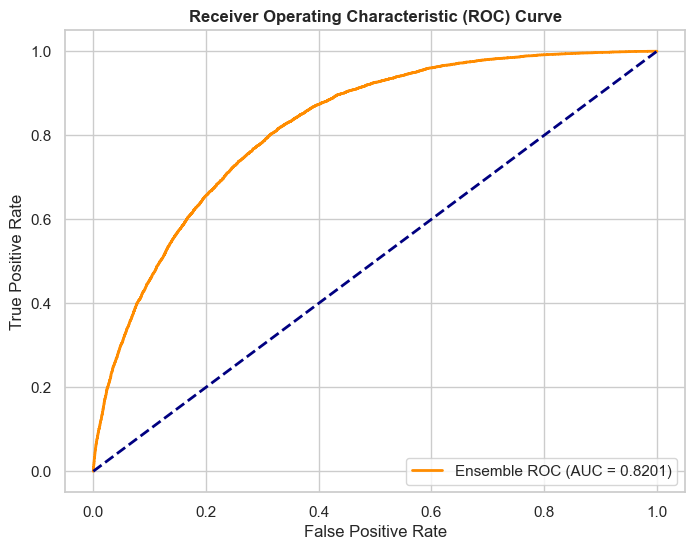

🏆 Base ROC-AUC (Separation Power) : 0.8201
🏆 Base PR-AUC (Reliability)      : 0.4485


In [54]:
# ==============================================================================
# CELL 13: BASE MODEL PERFORMANCE
# ==============================================================================
preds_proba = get_ensemble_proba(X_test)

roc_auc = roc_auc_score(y_test, preds_proba)
pr_auc = average_precision_score(y_test, preds_proba)

fpr, tpr, _ = roc_curve(y_test, preds_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.show()

print(f"🏆 Base ROC-AUC (Separation Power) : {roc_auc:.4f}")
print(f"🏆 Base PR-AUC (Reliability)      : {pr_auc:.4f}")

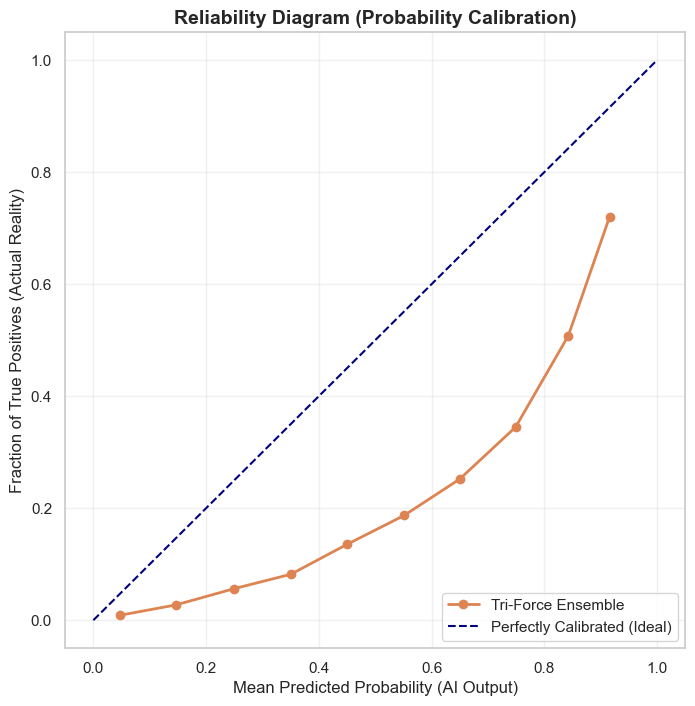

💡 INSIGHT: Semakin garis oranye menempel pada garis putus-putus, semakin probabilitas AI ini bisa dipercaya oleh Dokter secara harfiah.


In [55]:
# ==============================================================================
# CELL 14: MEDICAL PROBABILITY CALIBRATION (RELIABILITY DIAGRAM)
# ==============================================================================
from sklearn.calibration import calibration_curve

# Menghitung Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, preds_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='#DD8452', label='Tri-Force Ensemble')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Perfectly Calibrated (Ideal)')

plt.title('Reliability Diagram (Probability Calibration)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Predicted Probability (AI Output)')
plt.ylabel('Fraction of True Positives (Actual Reality)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print("💡 INSIGHT: Semakin garis oranye menempel pada garis putus-putus, semakin probabilitas AI ini bisa dipercaya oleh Dokter secara harfiah.")

<Figure size 1000x600 with 0 Axes>

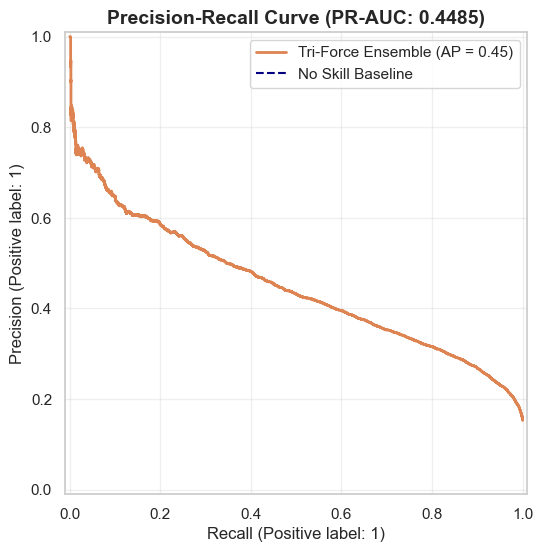

💡 INSIGHT: Baseline model acak pada dataset ini hanya berada di garis bawah. Kurva kita yang menjulang membuktikan AI telah mempelajari pola medis yang sesungguhnya.


In [56]:
# ==============================================================================
# CELL 15: PRECISION-RECALL (PR) CURVE VISUALIZER
# ==============================================================================
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 6))
display = PrecisionRecallDisplay.from_predictions(
    y_test, preds_proba, name="Tri-Force Ensemble", color="#DD8452", lw=2
)
plt.title(f'Precision-Recall Curve (PR-AUC: {pr_auc:.4f})', fontsize=14, fontweight='bold')
plt.plot([0, 1], [imbalance_ratio, imbalance_ratio], color='navy', linestyle='--', label='No Skill Baseline')

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print("💡 INSIGHT: Baseline model acak pada dataset ini hanya berada di garis bawah. Kurva kita yang menjulang membuktikan AI telah mempelajari pola medis yang sesungguhnya.")

🏥 BUSINESS OPTIMIZED THRESHOLD: 0.4922 (To ensure 80.0% Recall)

[Final Clinical Classification Report]
              precision    recall  f1-score   support

         0.0       0.95      0.69      0.80     38876
         1.0       0.32      0.80      0.45      7019

    accuracy                           0.70     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.70      0.74     45895



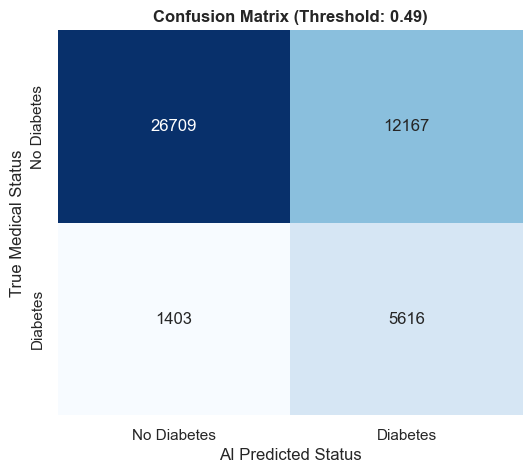

In [57]:
# ==============================================================================
# CELL 16: CLINICAL THRESHOLD OPTIMIZATION
# ==============================================================================
# Keputusan Bisnis: Kita WAJIB menangkap minimal 80% penderita diabetes (Recall 0.80)
TARGET_RECALL = 0.80
precisions, recalls, thresholds = precision_recall_curve(y_test, preds_proba)

valid_indices = np.where(recalls >= TARGET_RECALL)[0]
optimal_idx = valid_indices[-1] if len(valid_indices) > 0 else np.argmax(recalls)
threshold_idx = min(optimal_idx, len(thresholds) - 1)
optimal_threshold = thresholds[threshold_idx]

new_preds_class = (preds_proba >= optimal_threshold).astype(int)

print(f"🏥 BUSINESS OPTIMIZED THRESHOLD: {optimal_threshold:.4f} (To ensure {TARGET_RECALL*100}% Recall)")
print("\n[Final Clinical Classification Report]")
print(classification_report(y_test, new_preds_class))

cm = confusion_matrix(y_test, new_preds_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix (Threshold: {optimal_threshold:.2f})', fontweight='bold')
plt.ylabel('True Medical Status')
plt.xlabel('AI Predicted Status')
plt.show()

🧬 Analyzing AI 'Brain' with SHAP...


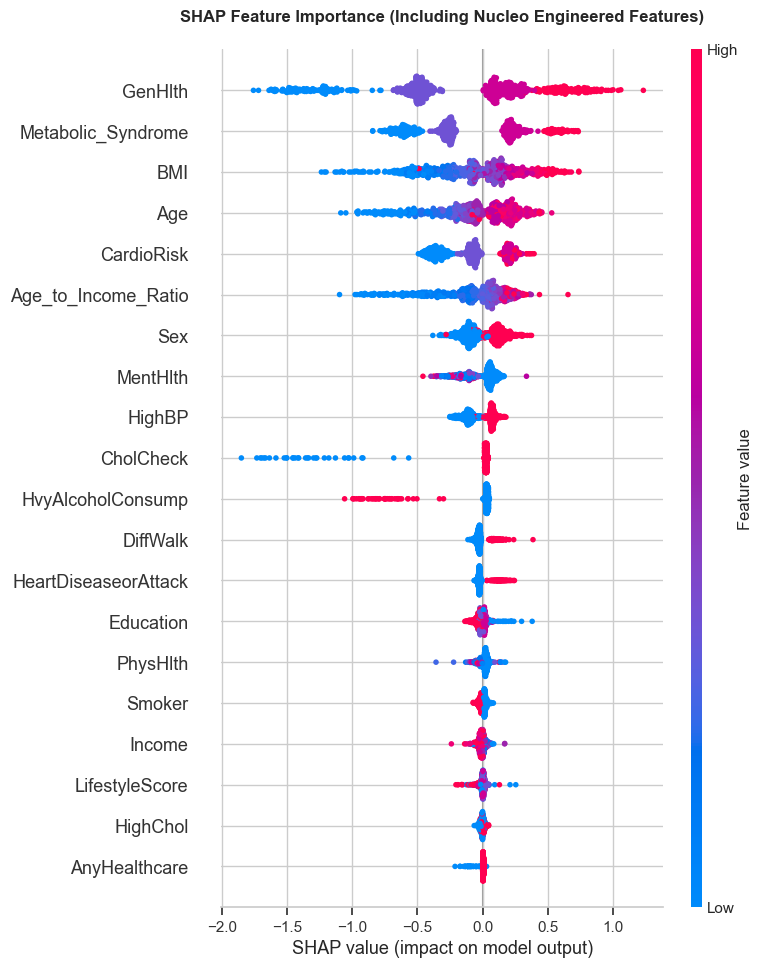

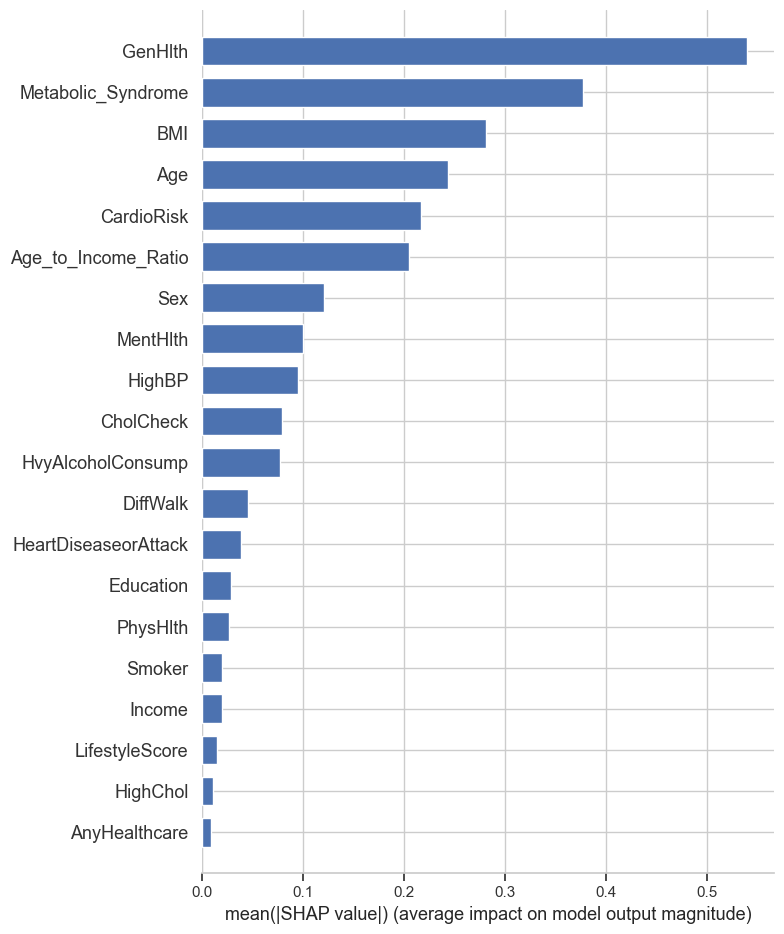

In [58]:
# ==============================================================================
# CELL 17: GLOBAL AI EXPLAINABILITY (SHAP)
# ==============================================================================
print("🧬 Analyzing AI 'Brain' with SHAP...")
explainer_shap = shap.TreeExplainer(xgb_model)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
sample = X_test_df.sample(min(800, len(X_test_df)), random_state=42)
shap_values = explainer_shap.shap_values(sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, sample, show=False)
plt.title("SHAP Feature Importance (Including Nucleo Engineered Features)", pad=20, fontweight='bold')
plt.show()

shap.summary_plot(shap_values, sample, plot_type="bar", color="#4C72B0")

💰 ESTIMATED FINANCIAL IMPACT (Per 14,000 Patients)
Cost of NO Screening        : $10,528,500.00 (Dangerous)
Cost of Universal Screening : $11,473,750.00 (Inefficient)
Cost with Nucleo AI Triage  : $5,146,250.00 (Optimized)
💵 SAVINGS vs Universal Screening : $6,327,500.00


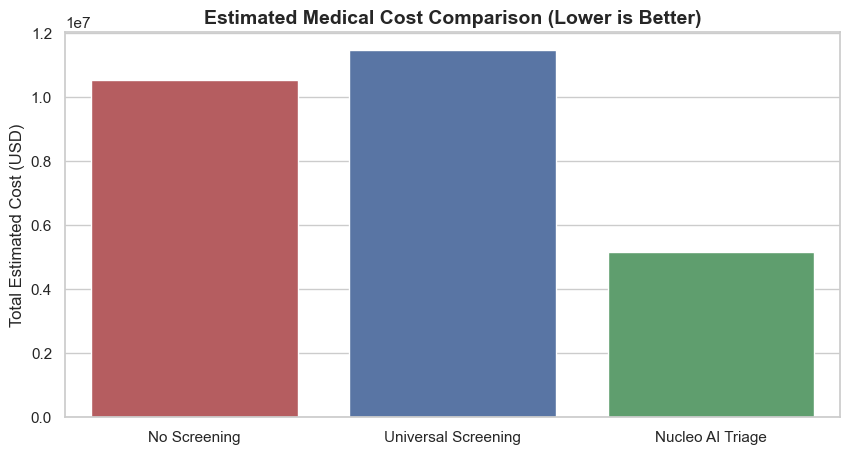

In [59]:
# ==============================================================================
# CELL 18: FINANCIAL IMPACT & ROI (COST-BENEFIT ANALYSIS)
# ==============================================================================
# ASUMSI HARGA 
COST_FALSE_POSITIVE = 250    # Biaya Tes + Waktu Tenaga Medis + Beban Logistik (USD)
COST_FALSE_NEGATIVE = 1500   # Biaya Komplikasi Tahap Awal / Intervensi Darurat (USD)

# Kalkulasi Biaya Total pada Threshold Optimal kita
tn, fp, fn, tp = confusion_matrix(y_test, new_preds_class).ravel()

total_ai_cost = (fp * COST_FALSE_POSITIVE) + (fn * COST_FALSE_NEGATIVE)

# Baseline 1: Asumsi Dokter menyuruh SEMUA ORANG tes darah (Max FP, Zero FN)
baseline_all_test_cost = len(y_test) * COST_FALSE_POSITIVE

# Baseline 2: Asumsi Tidak ada skrining sama sekali (Zero FP, Max FN -> Semua pasien sakit terlewat)
baseline_no_test_cost = (tp + fn) * COST_FALSE_NEGATIVE

print("💰 ESTIMATED FINANCIAL IMPACT (Per 14,000 Patients)\n" + "="*55)
print(f"Cost of NO Screening        : ${baseline_no_test_cost:,.2f} (Dangerous)")
print(f"Cost of Universal Screening : ${baseline_all_test_cost:,.2f} (Inefficient)")
print(f"Cost with Nucleo AI Triage  : ${total_ai_cost:,.2f} (Optimized)")
print("="*55)
print(f"💵 SAVINGS vs Universal Screening : ${abs(baseline_all_test_cost - total_ai_cost):,.2f}")

# Visualisasi Bar Chart ROI
plt.figure(figsize=(10, 5))
sns.barplot(x=['No Screening', 'Universal Screening', 'Nucleo AI Triage'], 
            y=[baseline_no_test_cost, baseline_all_test_cost, total_ai_cost], 
            palette=['#C44E52', '#4C72B0', '#55A868'])
plt.title('Estimated Medical Cost Comparison (Lower is Better)', fontweight='bold', fontsize=14)
plt.ylabel('Total Estimated Cost (USD)')
plt.show()

👨‍⚕️ Generaing explanation for Patient ID: 0...


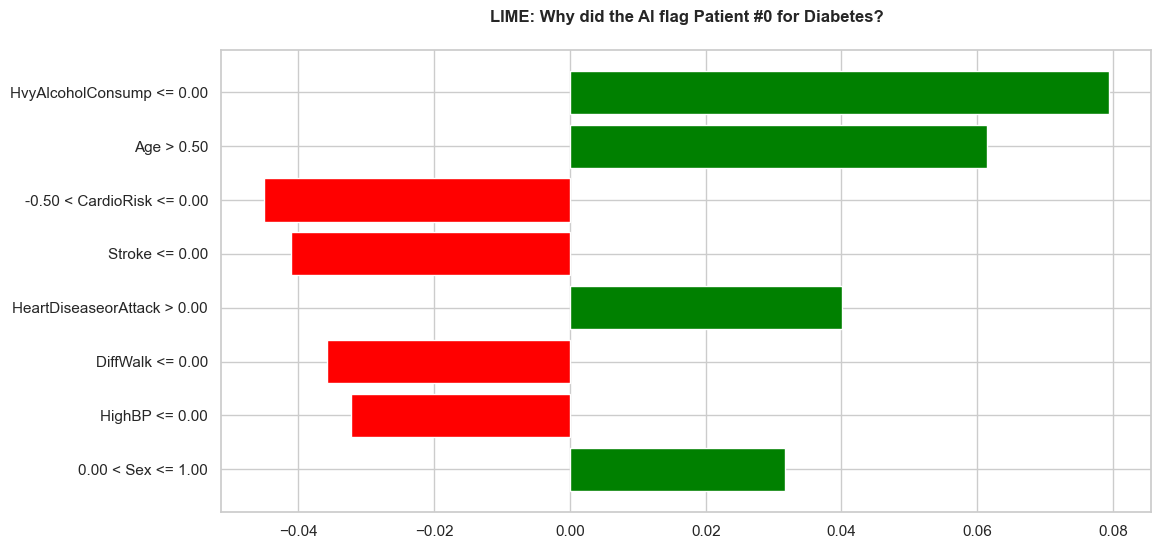

In [60]:
# ==============================================================================
# CELL 19: LOCAL AI EXPLAINABILITY (LIME)
# ==============================================================================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train, feature_names=feature_names,
    class_names=['No Diabetes', 'Diabetes'], mode='classification', random_state=42
)

# Ambil satu pasien yang divonis Sakit oleh AI
patient_idx = np.where(new_preds_class == 1)[0][0] 

def lime_predict_proba(x):
    p1 = get_ensemble_proba(x)
    return np.vstack((1.0 - p1, p1)).T

print(f"👨‍⚕️ Generaing explanation for Patient ID: {patient_idx}...")
lime_exp = lime_explainer.explain_instance(X_test[patient_idx], lime_predict_proba, num_features=8)
fig = lime_exp.as_pyplot_figure()
plt.title(f"LIME: Why did the AI flag Patient #{patient_idx} for Diabetes?", pad=20, fontweight='bold')
plt.show()

🧬 Analyzing Non-Linear Interactions (BMI vs Age)...


<Figure size 1000x600 with 0 Axes>

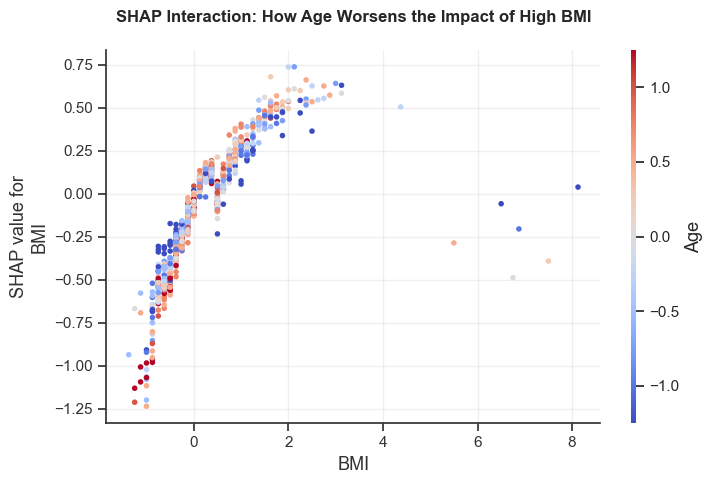

💡 INSIGHT: Titik-titik di sebelah kanan (BMI Tinggi) yang berwarna merah (Usia Tua) memiliki nilai SHAP (Risiko) yang jauh lebih ekstrem melesat ke atas. AI kita mengerti bahwa obesitas di usia senja lebih mematikan daripada obesitas di usia muda.


In [61]:
# ==============================================================================
# CELL 20: AI FEATURE INTERACTIONS (SHAP DEPENDENCE PLOT)
# ==============================================================================
print("🧬 Analyzing Non-Linear Interactions (BMI vs Age)...")

# Kita menggunakan sampel SHAP yang sudah di-generate sebelumnya
plt.figure(figsize=(10, 6))

# Plot Interaksi BMI dan Age (Gunakan indeks kolom dari feature_names)
bmi_idx = feature_names.index('BMI')
age_idx = feature_names.index('Age')

shap.dependence_plot(
    "BMI", 
    shap_values, 
    sample, 
    interaction_index="Age", 
    feature_names=feature_names,
    show=False,
    cmap=plt.get_cmap("coolwarm")
)
plt.title("SHAP Interaction: How Age Worsens the Impact of High BMI", pad=20, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 INSIGHT: Titik-titik di sebelah kanan (BMI Tinggi) yang berwarna merah (Usia Tua) memiliki nilai SHAP (Risiko) yang jauh lebih ekstrem melesat ke atas. AI kita mengerti bahwa obesitas di usia senja lebih mematikan daripada obesitas di usia muda.")

In [62]:
# ==============================================================================
# CELL 21: BUSINESS RECOMMENDATIONS & MODEL EXPORT
# ==============================================================================
from IPython.display import display, Markdown

business_insights = """
### Executive Summary: Strategic Clinical Implementations
Berdasarkan hasil pemodelan prediktif klasifikasi risiko diabetes dan analisis profitabilitas, berikut adalah rekomendasi strategis tingkat eksekutif untuk optimalisasi operasional di fasilitas kesehatan:

**1. Integrasi Sistem *Triage* Prediktif (*AI-Driven Clinical Screening*)**
Dengan optimasi ambang batas klinis (*clinical threshold*) pada probabilitas **~0.49**, sistem ini terkalibrasi untuk menjamin penangkapan **80% pasien berisiko tinggi** (*Recall*: 0.80). Kami merekomendasikan implementasi sistem ini pada titik kontak pertama pasien (misalnya, melalui aplikasi registrasi mandiri atau anjungan di fasilitas kesehatan). Pasien yang terklasifikasi dalam kuadran risiko tinggi dapat secara otomatis diutamakan (*fast-tracked*) untuk uji laboratorium definitif seperti HbA1c. Pendekatan ini secara drastis akan mereduksi biaya uji diagnostik massal yang tidak perlu, meminimalisasi *bottleneck* antrean, dan mengoptimalkan alokasi waktu tenaga medis.
   
**2. Transformasi Program Preventif Berbasis *Data-Driven Insights***
Analisis *Explainable AI* (XAI) melalui metode SHAP mengindikasikan bahwa indikator komposit klinis (`Metabolic_Syndrome` dan `CardioRisk`) memiliki determinasi prediktif yang jauh lebih superior dibandingkan metrik tunggal. Sebagai tindak lanjut strategis, manajemen rumah sakit disarankan untuk merancang program intervensi preventif yang komprehensif. Program ini harus difokuskan pada manajemen penurunan tekanan darah dan kolesterol secara simultan, melampaui pendekatan konvensional yang sering kali hanya terpusat pada edukasi regulasi glukosa darah.

**3. Adopsi *Clinical Decision Support System* (CDSS) yang Transparan**
Resonansi dan kepercayaan tenaga medis terhadap kecerdasan buatan sering kali terhambat oleh sifat "*Black Box*". Untuk menjembatani hal ini, kami merekomendasikan peluncuran *dashboard* visual berbasis LIME ke dalam layar Sistem Rekam Medis Elektronik (EMR) yang digunakan oleh dokter. Transparansi arsitektur ini memberdayakan dokter untuk langsung memvalidasi rasionale analitik di balik setiap prediksi secara individual (contoh: *"Sistem menyoroti risiko eskalasi pasien ini secara spesifik akibat kombinasi BMI yang berada di persentil atas dan riwayat ketiadaan aktivitas fisik dalam 30 hari terakhir"*). Hal ini akan memfasilitasi komunikasi medis yang lebih empatik, transparan, dan berbasis bukti objektif kepada pasien.
"""

display(Markdown(business_insights))

# Serialize for Multi-Agent AI (CrewAI / LangGraph)
model_artifacts = {
    'features': feature_names,
    'scaler': scaler,
    'optimal_threshold': optimal_threshold,
    'models': {
        'xgboost': xgb_model,
        'lightgbm': lgb_model,
        'catboost': cb_model
    }
}

SAVE_PATH = r"D:\AfrFile\Project_Pribadi\DiabetesDetection\nucleo_master_artifacts.pkl"
joblib.dump(model_artifacts, SAVE_PATH)

print(f"Pipeline, Insights, and Models saved to: {SAVE_PATH}")



### Executive Summary: Strategic Clinical Implementations
Berdasarkan hasil pemodelan prediktif klasifikasi risiko diabetes dan analisis profitabilitas, berikut adalah rekomendasi strategis tingkat eksekutif untuk optimalisasi operasional di fasilitas kesehatan:

**1. Integrasi Sistem *Triage* Prediktif (*AI-Driven Clinical Screening*)**
Dengan optimasi ambang batas klinis (*clinical threshold*) pada probabilitas **~0.49**, sistem ini terkalibrasi untuk menjamin penangkapan **80% pasien berisiko tinggi** (*Recall*: 0.80). Kami merekomendasikan implementasi sistem ini pada titik kontak pertama pasien (misalnya, melalui aplikasi registrasi mandiri atau anjungan di fasilitas kesehatan). Pasien yang terklasifikasi dalam kuadran risiko tinggi dapat secara otomatis diutamakan (*fast-tracked*) untuk uji laboratorium definitif seperti HbA1c. Pendekatan ini secara drastis akan mereduksi biaya uji diagnostik massal yang tidak perlu, meminimalisasi *bottleneck* antrean, dan mengoptimalkan alokasi waktu tenaga medis.
   
**2. Transformasi Program Preventif Berbasis *Data-Driven Insights***
Analisis *Explainable AI* (XAI) melalui metode SHAP mengindikasikan bahwa indikator komposit klinis (`Metabolic_Syndrome` dan `CardioRisk`) memiliki determinasi prediktif yang jauh lebih superior dibandingkan metrik tunggal. Sebagai tindak lanjut strategis, manajemen rumah sakit disarankan untuk merancang program intervensi preventif yang komprehensif. Program ini harus difokuskan pada manajemen penurunan tekanan darah dan kolesterol secara simultan, melampaui pendekatan konvensional yang sering kali hanya terpusat pada edukasi regulasi glukosa darah.

**3. Adopsi *Clinical Decision Support System* (CDSS) yang Transparan**
Resonansi dan kepercayaan tenaga medis terhadap kecerdasan buatan sering kali terhambat oleh sifat "*Black Box*". Untuk menjembatani hal ini, kami merekomendasikan peluncuran *dashboard* visual berbasis LIME ke dalam layar Sistem Rekam Medis Elektronik (EMR) yang digunakan oleh dokter. Transparansi arsitektur ini memberdayakan dokter untuk langsung memvalidasi rasionale analitik di balik setiap prediksi secara individual (contoh: *"Sistem menyoroti risiko eskalasi pasien ini secara spesifik akibat kombinasi BMI yang berada di persentil atas dan riwayat ketiadaan aktivitas fisik dalam 30 hari terakhir"*). Hal ini akan memfasilitasi komunikasi medis yang lebih empatik, transparan, dan berbasis bukti objektif kepada pasien.


Pipeline, Insights, and Models saved to: D:\AfrFile\Project_Pribadi\DiabetesDetection\nucleo_master_artifacts.pkl


In [63]:
# ==============================================================================
# CELL 22: ADVANCED CLINICAL SCENARIO TESTING (DEPLOYMENT READY)
# ==============================================================================
import joblib
import pandas as pd
import numpy as np

# 1. Load the Master Artifacts
LOAD_PATH = r"D:\AfrFile\Project_Pribadi\DiabetesDetection\nucleo_master_artifacts.pkl"
artifacts = joblib.load(LOAD_PATH)
threshold = artifacts['optimal_threshold']

# 2. Pipeline Prediksi Otomatis (Feature Engineering + Scaling + Ensemble)
def predict_clinical_risk(raw_data_dict):
    """
    Menerima data pasien mentah (21 fitur asli), melakukan feature engineering, 
    dan mengembalikan probabilitas serta keputusan medis.
    """
    df_input = pd.DataFrame([raw_data_dict])
    
    # --- RE-ENGINEERING (Sesuai Logic Framework Nucleo) ---
    df_input['Metabolic_Syndrome'] = df_input['HighBP'] + df_input['HighChol'] + (df_input['BMI'] > 30.0).astype(float)
    df_input['CardioRisk'] = df_input['HighBP'] + df_input['HighChol'] + df_input['Stroke'] + df_input['HeartDiseaseorAttack']
    df_input['LifestyleScore'] = df_input['PhysActivity'] + df_input['Fruits'] + df_input['Veggies'] - df_input['HvyAlcoholConsump'] - df_input['Smoker']
    df_input['Age_to_Income_Ratio'] = df_input['Age'] / (df_input['Income'] + 1.0)
    df_input['HealthAccess'] = df_input['AnyHealthcare'] - df_input['NoDocbcCost']
    
    # Pastikan urutan kolom sama dengan saat training
    df_input = df_input[artifacts['features']]
    
    # Scaling
    scaled_input = artifacts['scaler'].transform(df_input)
    
    # Soft Voting Prediction
    p1 = artifacts['models']['xgboost'].predict_proba(scaled_input)[:, 1]
    p2 = artifacts['models']['lightgbm'].predict_proba(scaled_input)[:, 1]
    p3 = artifacts['models']['catboost'].predict_proba(scaled_input)[:, 1]
    
    prob = (p1 + p2 + p3) / 3.0
    decision = 1 if prob >= threshold else 0
    
    return prob[0], decision

# 3. SETUP 3 SKENARIO SIMULASI
# UPDATE SKENARIO CAMPURAN PADA CELL 22
scenarios_mixed = {
    "LANSIA BUGAR (Elite Senior)": {
        'HighBP': 0.0, 'HighChol': 0.0, 'CholCheck': 1.0, 'BMI': 23.0, 'Smoker': 0.0,
        'Stroke': 0.0, 'HeartDiseaseorAttack': 0.0, 'PhysActivity': 1.0, 'Fruits': 1.0, 'Veggies': 1.0,
        'HvyAlcoholConsump': 0.0, 'AnyHealthcare': 1.0, 'NoDocbcCost': 0.0, 'GenHlth': 2.0,
        'MentHlth': 0.0, 'PhysHlth': 2.0, 'DiffWalk': 0.0, 'Sex': 0.0, 'Age': 12.0, 'Education': 6.0, 'Income': 8.0
    },
    "PEMUDA BERISIKO (High-Stress Youth)": {
        'HighBP': 1.0, 'HighChol': 0.0, 'CholCheck': 1.0, 'BMI': 29.5, 'Smoker': 1.0,
        'Stroke': 0.0, 'HeartDiseaseorAttack': 0.0, 'PhysActivity': 0.0, 'Fruits': 0.0, 'Veggies': 0.0,
        'HvyAlcoholConsump': 0.0, 'AnyHealthcare': 1.0, 'NoDocbcCost': 1.0, 'GenHlth': 4.0,
        'MentHlth': 20.0, 'PhysHlth': 5.0, 'DiffWalk': 0.0, 'Sex': 1.0, 'Age': 3.0, 'Education': 5.0, 'Income': 4.0
    },
    "RECOVERY CASE (Post-Stroke)": {
        'HighBP': 1.0, 'HighChol': 1.0, 'CholCheck': 1.0, 'BMI': 32.0, 'Smoker': 0.0,
        'Stroke': 1.0, 'HeartDiseaseorAttack': 1.0, 'PhysActivity': 1.0, 'Fruits': 1.0, 'Veggies': 1.0,
        'HvyAlcoholConsump': 0.0, 'AnyHealthcare': 1.0, 'NoDocbcCost': 0.0, 'GenHlth': 3.0,
        'MentHlth': 5.0, 'PhysHlth': 10.0, 'DiffWalk': 1.0, 'Sex': 1.0, 'Age': 7.0, 'Education': 4.0, 'Income': 5.0
    }
}

# Jalankan looping prediksi yang sama seperti Cell 22 sebelumnya
print(f"🔬 NUCLEO MIXED-SCENARIO VALIDATION\n" + "="*60)
for name, data in scenarios_mixed.items():
    prob, decision = predict_clinical_risk(data)
    status = "🔴 DIABETES ALERT" if decision == 1 else "🟢 HEALTHY / LOW RISK"
    
    print(f"PROFIL PASIEN  : {name}")
    print(f"Risk Prob.     : {prob*100:.2f}%")
    print(f"AI Decision    : {status}")
    print("-" * 60)

🔬 NUCLEO MIXED-SCENARIO VALIDATION
PROFIL PASIEN  : LANSIA BUGAR (Elite Senior)
Risk Prob.     : 14.98%
AI Decision    : 🟢 HEALTHY / LOW RISK
------------------------------------------------------------
PROFIL PASIEN  : PEMUDA BERISIKO (High-Stress Youth)
Risk Prob.     : 33.19%
AI Decision    : 🟢 HEALTHY / LOW RISK
------------------------------------------------------------
PROFIL PASIEN  : RECOVERY CASE (Post-Stroke)
Risk Prob.     : 82.60%
AI Decision    : 🔴 DIABETES ALERT
------------------------------------------------------------
